# Pytorch workflow

In [391]:
what_were_covering = {1: "data and load",
                      2: "build model",
                      3: "taring",
                      4: "making predictions and evaluting a model (inference)",
                      5: "saving and loading a trained model",
                      6: "putting it all together"}

what_were_covering


{1: 'data and load',
 2: 'build model',
 3: 'taring',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading a trained model',
 6: 'putting it all together'}

In [392]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

## Data 
* Excel Speadsheet
* Image of any kind
* Videos (YT)
* Audio like songs
* DNA & RNA
* Text

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation

In [393]:
# Linear regression formula: y = ax + b

# Create known parameters
weight = 0.7
bias = 0.3

# Create 
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
print(f"{X.shape})")
y = weight * X + bias # y = ax + b

X[:10], y[:10]

torch.Size([50, 1]))


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [394]:
len(X), len(y)


(50, 50)

### Splitting data into training and test sets **IMPORTANT**
* Training set 60~80(%)
* Validation set (ofter) 10 ~ 20(%)
* Testing set 10 ~ 20(%)

In [395]:
# Create a train/test split
train_split = int(0.8 * len(X))
print(train_split)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

40


(40, 40, 10, 10)

### Visualize data 
"Visualize visualize and visualize"

In [396]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [397]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        # Plot the predictions if they exist
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    # Show the legend
    plt.legend(prop={"size": 14})

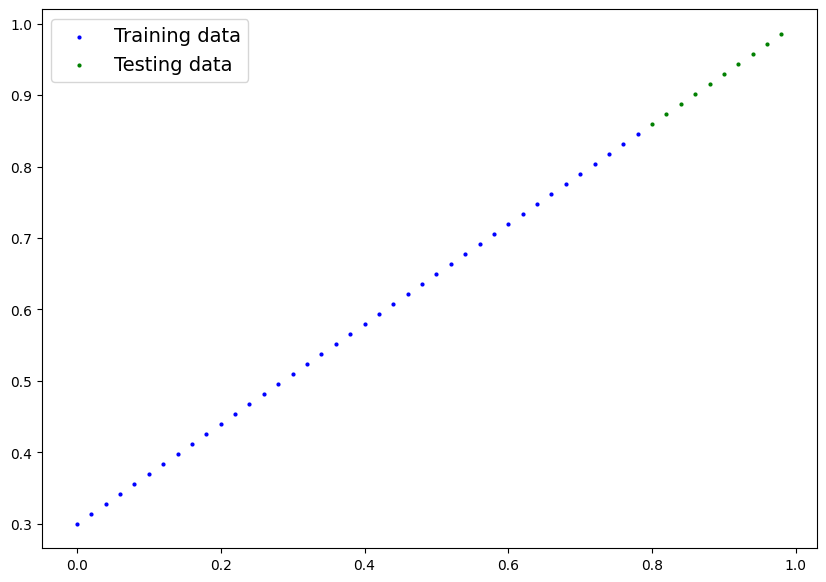

In [398]:
plot_predictions()

## Build model - Linear regression

* Start with random values (weights & bias)
* Look at training data & adjust the random values to better respesent (or get closer to) thew ideal values (the weights * bias values we used to create the data)

Through two main algorithms:
1. Gradient descent
2. Backpropagation


In [399]:
from torch import nn
# Create linear regreesion model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                              requires_grad= True, # Gradient descent [ON]
                                              dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                           requires_grad= True,
                                           dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is commonly used as input in the forward method
        return self.weights * x + self.bias # Linear regression formula: y = ax + b

### Pytorch model building essential

* torch.nn - for computational graph (nerual network) 
* torch.nn.Parameter - what parameter should our model try and learn ofter apply PyTorch layer from torch.nn will set for us
* torch.nn.Module - The base class for all nerual network modules, should overwrite forward() 
* torch.optim - where the optimizer in PyTorch live, will help with gradient descent
* def forward() - what happens in the forward computation  

### Checking the contents of our PyTorch model
See what's inside using `.Parameters()`.

In [400]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model 
model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [401]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [402]:
weight, bias

(0.7, 0.3)

### Making prediction using `torch.inference_mode()`

To check how well it predicts `y_test` based on `X_test`

pass through our model, it's going to run it through the `forward()` method

In [403]:
X_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [404]:
y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [405]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds


tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [406]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

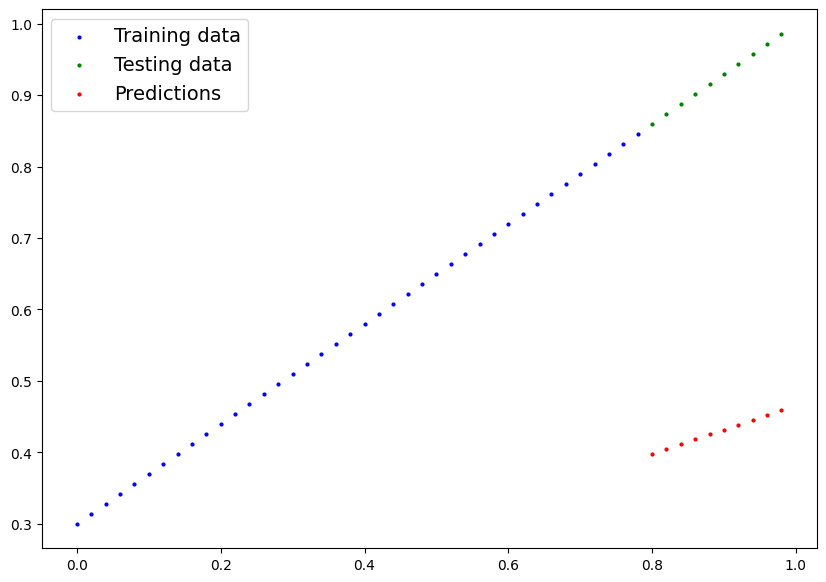

In [407]:
plot_predictions(predictions=y_preds)

## Training & testing model

For a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

In other words frome a poor representation of the data to a better represenntation of the data.

One way to measure how poor or how wrong a models predictions are is to use a **loss function**

* Note: Loss function may also be called **cost function** or **criterion** in different areas.

Things we need to train:

* **Loss function / Criterion / Cost function:** A function to measure how wrong your model's predictions are to the  ideal output, **lower is better**
* **Optimizer:** Take into account the loss of a model and adjusts the model's parameters (e.g weight & bias) to improve the loss function.

we need:
* A training loop
* A testing loop


In [408]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [409]:
# check out our model's parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [410]:
# Setup a loss function
loss_fn = nn.L1Loss() # Mean Absolute Error (MAE)

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01) # learning rate = possibly the most important hyperparameter in training a model

### Building training loop & testing loop

A couple of things we need in a training loop:
0. Loop through the data
1. Forward pass (involves data moving through our model's `forward()` to make predictions on data - also called forward propagation)
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**Backpropagations**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [411]:
torch.manual_seed(42)

# An epochs is one loop through the data... (this is a hyperparameter we can tune)
epochs = 200

# Track different values of loss and epoch count
epoch_count = []
loss_values = []
test_loss_values = []

### Training 
# 0. Loop through the data
for epoch in range(epochs):

    # Set model to training mode
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients and vice versa for eval mode

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)
    print(f"Loss: {loss}")

    # 3. Optimize zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameters of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)
    optimizer.step() # by default how the optimizer changes will acculumate through the loop. Have to zero them above in step 3.

    ### Testiung
    model_0.eval() # turn off settings not need for evaluation (dropout, batchNorm, etc)
    with torch.inference_mode(): # turn off gradient tracking & computations
        
        # 1. Forward pass
        test_pred = model_0(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:

        epoch_count.append(epoch)
        loss_values.append(loss.item())
        test_loss_values.append(test_loss.item())

        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

        # Model State
        print(model_0.state_dict())

Loss: 0.31288138031959534
Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637
Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Loss: 0.08227583020925522
Loss: 0

In [412]:
weight, bias

(0.7, 0.3)

In [413]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [414]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

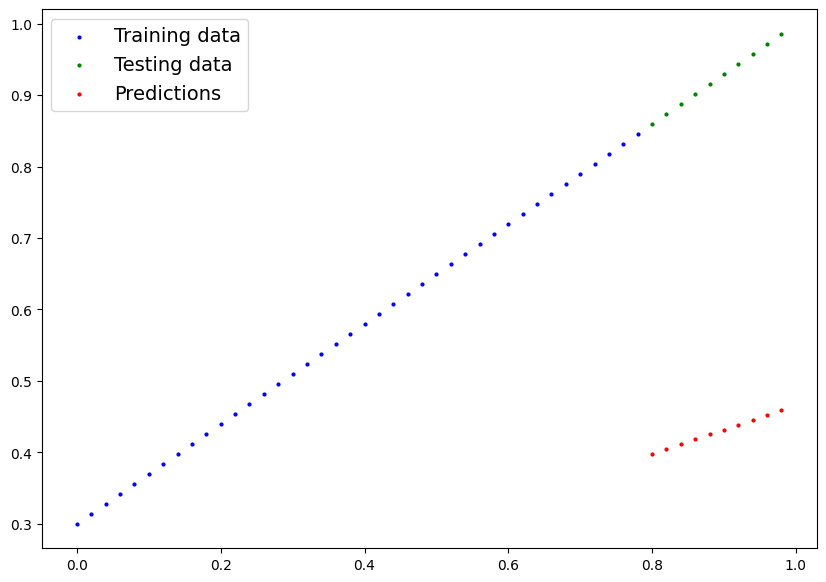

In [415]:
plot_predictions(predictions=y_preds)

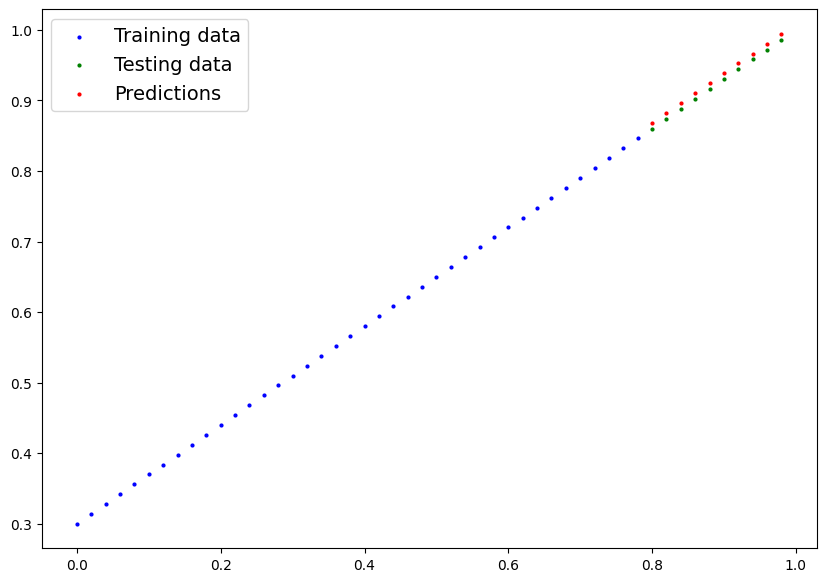

In [416]:
plot_predictions(predictions=y_preds_new)

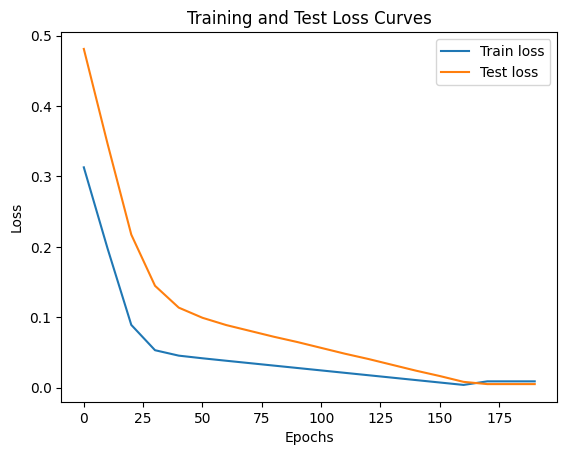

In [417]:
# Plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Test Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## Saving a model

There 3 main methods

1. `torch.save()` - allows saving a PyTorch object in Python pickle format
2. `torch.load()` - allows loading a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - allows to load a model's saved state dictionary (e.g bias / weight)


In [418]:
model_0.state_dict()

# Saving PyTorch models
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME # Slash instead of math operator <- Pathlib

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

Saving model to: models\01_pytorch_workflow.pth


In [419]:
ls -l models

 Volume in drive C is Windows
 Volume Serial Number is 2ADB-1281

 Directory of c:\DeepLearning\Pytorch\Pytorch101\notebooks


 Directory of c:\DeepLearning\Pytorch\Pytorch101\notebooks\models

2026/05/05  �U�� 11:12    <DIR>          .
2026/05/05  �U�� 11:11    <DIR>          ..
2026/05/06  �U�� 03:10             1,989 01_pytorch_workflow.pth
               1 File(s)          1,989 bytes
               2 Dir(s)  224,195,829,760 bytes free


File Not Found


In [420]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

## Loading a model

In [421]:
# To load in a saved stata_dict, have to instantiate a new instance of model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict (model parameters)
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [422]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [423]:
# Make some predictions with the loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_y_preds = loaded_model_0(X_test)
loaded_y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [424]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [425]:
# Compare loaded model preds with original model preds
loaded_y_preds == y_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Putting it all together
See it all in one place

In [426]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.11.0+cu128'

## Create device-agnostic code


In [427]:
# device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [428]:
!nvidia-smi

Wed May  6 15:10:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.97                 Driver Version: 595.97         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070      WDDM  |   00000000:01:00.0  On |                  N/A |
| 30%   36C    P5             27W /  198W |    2309MiB /   8192MiB |     23%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Data

In [429]:
# Create some data using linear regression formula: y = weight * X + bias
weight = 0.8
bias = 0.2

# Create range value
start = 0
end = 1
step = 0.02

# Create X and y (feature and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # unsqueeze to add an extra dimension for features
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2000],
         [0.2160],
         [0.2320],
         [0.2480],
         [0.2640],
         [0.2800],
         [0.2960],
         [0.3120],
         [0.3280],
         [0.3440]]))

In [430]:
# Split data into training and test sets (80% train, 20% test)
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

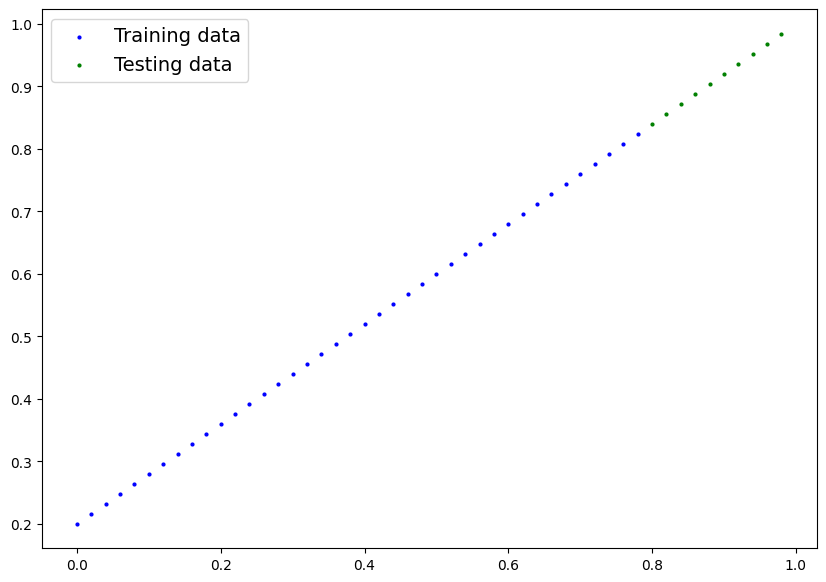

In [431]:
# Plot predictions of loaded model
plot_predictions(X_train, y_train, X_test, y_test)

## Build PyTorch Linear model

In [432]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating model parameters / also called linear transform, probing layer, fully connected layer, dense layer, etc.
        self.linear_Layer = nn.Linear(in_features=1, out_features=1) # in_features = number of features, out_features = number of outputs (labels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_Layer(x) # Linear regression formula y = ax + b implemented by nn.Linear() layer
    
# Set the manul seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()


(LinearRegressionModelV2(
   (linear_Layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_Layer.weight', tensor([[0.7645]])),
              ('linear_Layer.bias', tensor([0.8300]))]))

In [433]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.2000],
         [0.2160],
         [0.2320],
         [0.2480],
         [0.2640]]))

In [434]:
# Check the model device
next(model_1.parameters()).device

device(type='cpu')

In [435]:
# Set the model to use the target 
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### Training & Testing

For training we need:
* Loss function
* Optimizer
* Training loop
    * Forward Pass
    * Calculate loss
    * Zero grad optimizer
    * Backprop
    * Optimizer Step 
* Testing loop


In [436]:
X_train.device, y_train.device, X_test.device, y_test.device

(device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'))

In [437]:
# Set up loss function
loss_fn = nn.L1Loss() # MAE

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01) # Stochastic Gradient Descent (SGD) optimizer with learning rate of 0.01

# Put data to the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Training loop
torch.manual_seed(42)
epochs = 200
epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    # Set model to training mode
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    # 3. Optimize zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Loss: 0.6161779761314392 | Test loss: 0.5849761962890625
Epoch: 10 | Loss: 0.5009680986404419 | Test loss: 0.45026636123657227
Epoch: 20 | Loss: 0.3857581913471222 | Test loss: 0.3155565857887268
Epoch: 30 | Loss: 0.2705483138561249 | Test loss: 0.180846706032753
Epoch: 40 | Loss: 0.15533845126628876 | Test loss: 0.046136897057294846
Epoch: 50 | Loss: 0.05875825881958008 | Test loss: 0.06886561214923859
Epoch: 60 | Loss: 0.04580378159880638 | Test loss: 0.09473040699958801
Epoch: 70 | Loss: 0.041819483041763306 | Test loss: 0.09405827522277832
Epoch: 80 | Loss: 0.03831038996577263 | Test loss: 0.08853326737880707
Epoch: 90 | Loss: 0.034879546612501144 | Test loss: 0.08094760775566101
Epoch: 100 | Loss: 0.03144557774066925 | Test loss: 0.07267507165670395
Epoch: 110 | Loss: 0.028006771579384804 | Test loss: 0.06440252810716629
Epoch: 120 | Loss: 0.024577612057328224 | Test loss: 0.056816864758729935
Epoch: 130 | Loss: 0.021141953766345978 | Test loss: 0.04854437708854675
Epoc

In [438]:
print(f"Model weights: {weight} | Model bias: {bias}\n")
print(model_1.state_dict())


Model weights: 0.8 | Model bias: 0.2

OrderedDict([('linear_Layer.weight', tensor([[0.7987]], device='cuda:0')), ('linear_Layer.bias', tensor([0.2095], device='cuda:0'))])


### Plot predictions

In [439]:
# Trun on eval mode
model_1.eval()

# Make predictions with model
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8484],
        [0.8644],
        [0.8804],
        [0.8964],
        [0.9123],
        [0.9283],
        [0.9443],
        [0.9603],
        [0.9762],
        [0.9922]], device='cuda:0')

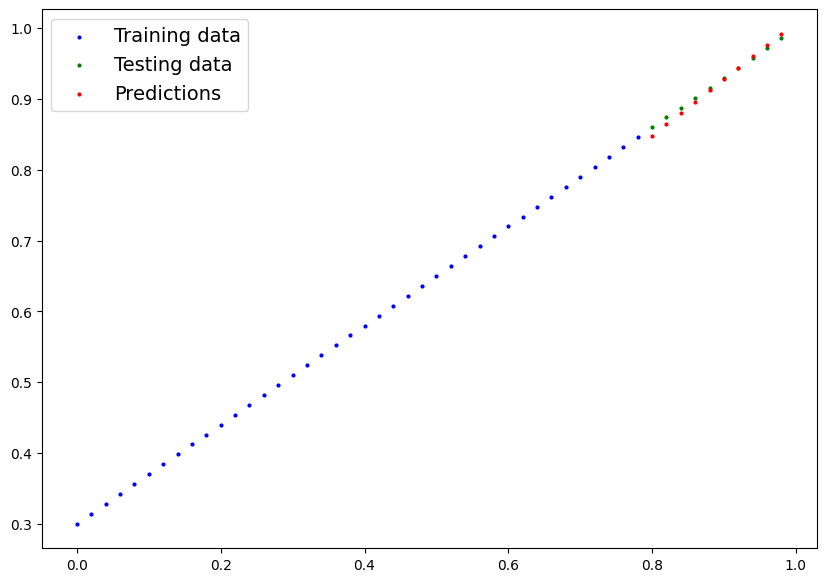

In [440]:
# Check out model predictions
plot_predictions(predictions=y_preds.cpu())